# Compare Untouched and Retrained MPNet SentenceTransformer

This notebook loads the two saved MPNet SentenceTransformer encoders and their tuned One-vs-Rest classifiers, evaluates both on the same untouched test split, and saves a comparison report.

Run `01-mpnet_retraining.ipynb` and `02-mpnet_ovr_logistic_regression.ipynb` first.


In [40]:
from pathlib import Path
import json
import time
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    f1_score,
    hamming_loss,
    multilabel_confusion_matrix,
)
from sentence_transformers import SentenceTransformer


In [41]:
path = Path.cwd().resolve()
for _ in range(8):
    if (path / "data" / "Restaurant_ABSA_processed.csv").exists():
        PROJECT_ROOT = path
        break
    path = path.parent
else:
    raise FileNotFoundError("Could not locate the project root")

DATA_PATH = PROJECT_ROOT / "data" / "Restaurant_ABSA_processed.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "MPNet"
MODEL_DIR = PROJECT_ROOT / "models" / "mpnet"
SPLIT_PATH = OUTPUT_DIR / "data_split.npz"
CLASSIFIER_ROOT = MODEL_DIR / "classifiers"
ENCODER_NAMES = ["unretrained", "retrained"]

required_paths = [DATA_PATH, SPLIT_PATH]
for encoder_name in ENCODER_NAMES:
    required_paths.extend([
        CLASSIFIER_ROOT / encoder_name / "model.joblib",
        CLASSIFIER_ROOT / encoder_name / "metadata.json",
    ])
for required_path in required_paths:
    if not required_path.exists():
        raise FileNotFoundError(f"Missing artifact: {required_path}")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [42]:
df = pd.read_csv(DATA_PATH).dropna(subset=["review_en"]).reset_index(drop=True)
split = np.load(SPLIT_PATH)
test_idx = split["test_idx"]

test_texts = df.loc[test_idx, "review_en"].astype(str).tolist()
y_test = df.loc[
    test_idx,
    ["food", "price", "service", "ambiance", "miscellaneous"],
].to_numpy(dtype=np.int8)

print("Test samples:", len(test_texts))


Test samples: 160


In [43]:
def apply_thresholds(probabilities, thresholds, aspect_cols):
    predictions = np.zeros_like(probabilities, dtype=np.int8)
    for index, aspect in enumerate(aspect_cols):
        predictions[:, index] = (
            probabilities[:, index] >= thresholds[aspect]
        ).astype(np.int8)

    empty_rows = np.flatnonzero(predictions.sum(axis=1) == 0)
    for row in empty_rows:
        predictions[row, np.argmax(probabilities[row])] = 1
    return predictions


def evaluate_bundle(encoder_name):
    bundle_dir = CLASSIFIER_ROOT / encoder_name
    classifier = joblib.load(bundle_dir / "model.joblib")
    with (bundle_dir / "metadata.json").open(
        encoding="utf-8",
    ) as file:
        metadata = json.load(file)

    encoder_path = PROJECT_ROOT / metadata["encoder_path"]
    encoder = SentenceTransformer(str(encoder_path))

    start = time.perf_counter()
    embeddings = encoder.encode(
        test_texts,
        batch_size=metadata["batch_size"],
        normalize_embeddings=metadata["normalize_embeddings"],
        convert_to_numpy=True,
        show_progress_bar=True,
    )
    probabilities = classifier.predict_proba(embeddings)
    elapsed = time.perf_counter() - start

    predictions = apply_thresholds(
        probabilities,
        metadata["thresholds"],
        metadata["aspect_cols"],
    )
    per_class_f1 = f1_score(
        y_test,
        predictions,
        average=None,
        zero_division=0,
    )

    metrics = {
        "encoder": encoder_name,
        "macro_f1": f1_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0,
        ),
        "micro_f1": f1_score(
            y_test,
            predictions,
            average="micro",
            zero_division=0,
        ),
        "samples_f1": f1_score(
            y_test,
            predictions,
            average="samples",
            zero_division=0,
        ),
        "hamming_loss": hamming_loss(y_test, predictions),
        "seconds": elapsed,
        "milliseconds_per_review": elapsed * 1000 / len(test_texts),
    }
    for index, aspect in enumerate(metadata["aspect_cols"]):
        metrics[f"{aspect}_f1"] = per_class_f1[index]

    return {
        "metadata": metadata,
        "metrics": metrics,
        "probabilities": probabilities,
        "predictions": predictions,
        "report": classification_report(
            y_test,
            predictions,
            target_names=metadata["aspect_cols"],
            output_dict=True,
            zero_division=0,
        ),
    }


In [44]:
evaluations = {
    encoder_name: evaluate_bundle(encoder_name)
    for encoder_name in ENCODER_NAMES
}

comparison_df = (
    pd.DataFrame([
        result["metrics"]
        for result in evaluations.values()
    ])
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

comparison_df.to_csv(
    OUTPUT_DIR / "encoder_comparison.csv",
    index=False,
)
comparison_df


Batches: 100%|██████████| 5/5 [00:05<00:00,  1.15s/it]


,encoder,macro_f1,micro_f1,samples_f1,hamming_loss,seconds,milliseconds_per_review,food_f1,price_f1,service_f1,ambiance_f1,miscellaneous_f1
0,retrained,0.811839,0.909091,0.909167,0.07375,5.752820,35.955122,0.964029,1.000000,0.913580,0.985507,0.196078
1,unretrained,0.710986,0.832817,0.834375,0.13500,4.731587,29.572420,0.925795,0.937143,0.705882,0.694444,0.291667


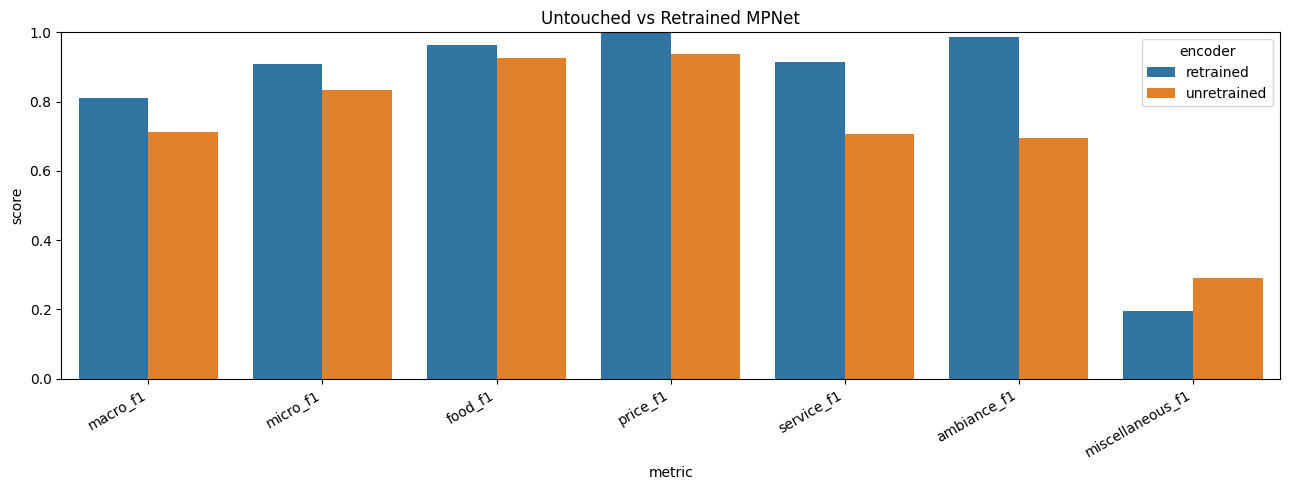

In [45]:
metric_columns = [
    "macro_f1",
    "micro_f1",
    "food_f1",
    "price_f1",
    "service_f1",
    "ambiance_f1",
    "miscellaneous_f1",
]

plot_df = comparison_df.melt(
    id_vars="encoder",
    value_vars=metric_columns,
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(13, 5))
sns.barplot(
    data=plot_df,
    x="metric",
    y="score",
    hue="encoder",
)
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.title("Untouched vs Retrained MPNet")
plt.tight_layout()
plt.show()



===== UNRETRAINED =====


,precision,recall,f1-score,support
food,0.879195,0.977612,0.925795,134.0
price,0.911111,0.964706,0.937143,85.0
service,0.923077,0.571429,0.705882,42.0
ambiance,0.675676,0.714286,0.694444,35.0
miscellaneous,0.205882,0.500000,0.291667,14.0
micro avg,0.800595,0.867742,0.832817,310.0
macro avg,0.718988,0.745606,0.710986,310.0
weighted avg,0.840506,0.867742,0.844354,310.0
samples avg,0.841667,0.872917,0.834375,310.0


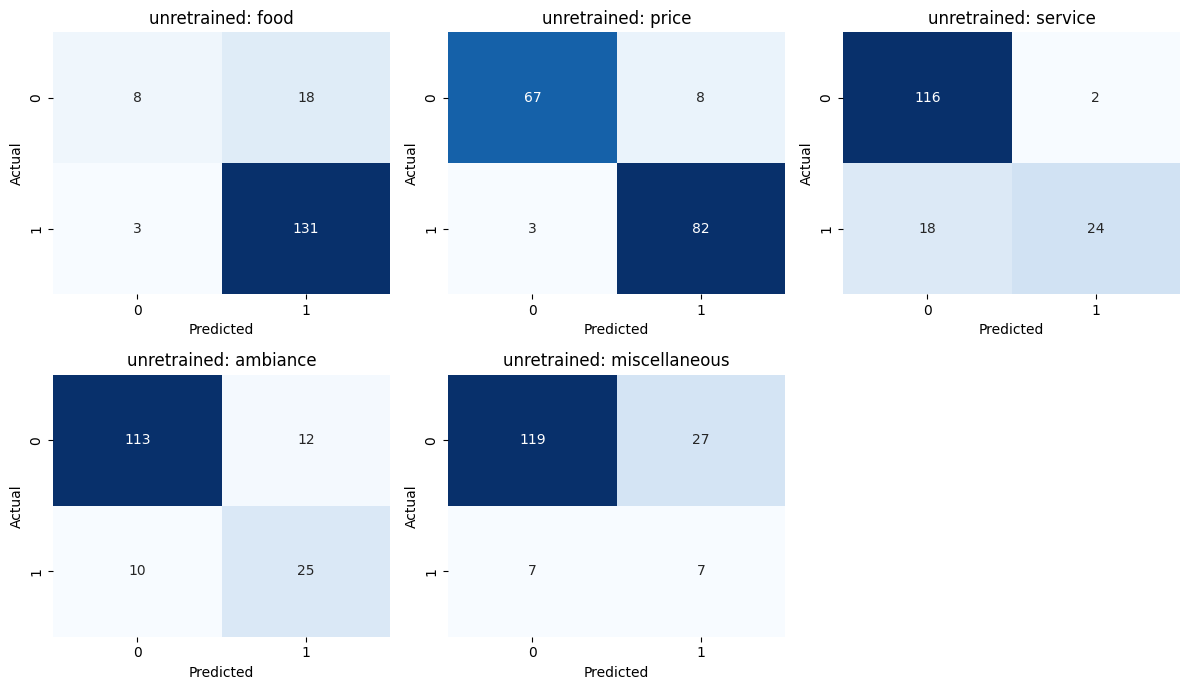


===== RETRAINED =====


,precision,recall,f1-score,support
food,0.930556,1.000000,0.964029,134.0
price,1.000000,1.000000,1.000000,85.0
service,0.948718,0.880952,0.913580,42.0
ambiance,1.000000,0.971429,0.985507,35.0
miscellaneous,0.135135,0.357143,0.196078,14.0
micro avg,0.870206,0.951613,0.909091,310.0
macro avg,0.802882,0.841905,0.811839,310.0
weighted avg,0.923976,0.951613,0.934800,310.0
samples avg,0.888542,0.954167,0.909167,310.0


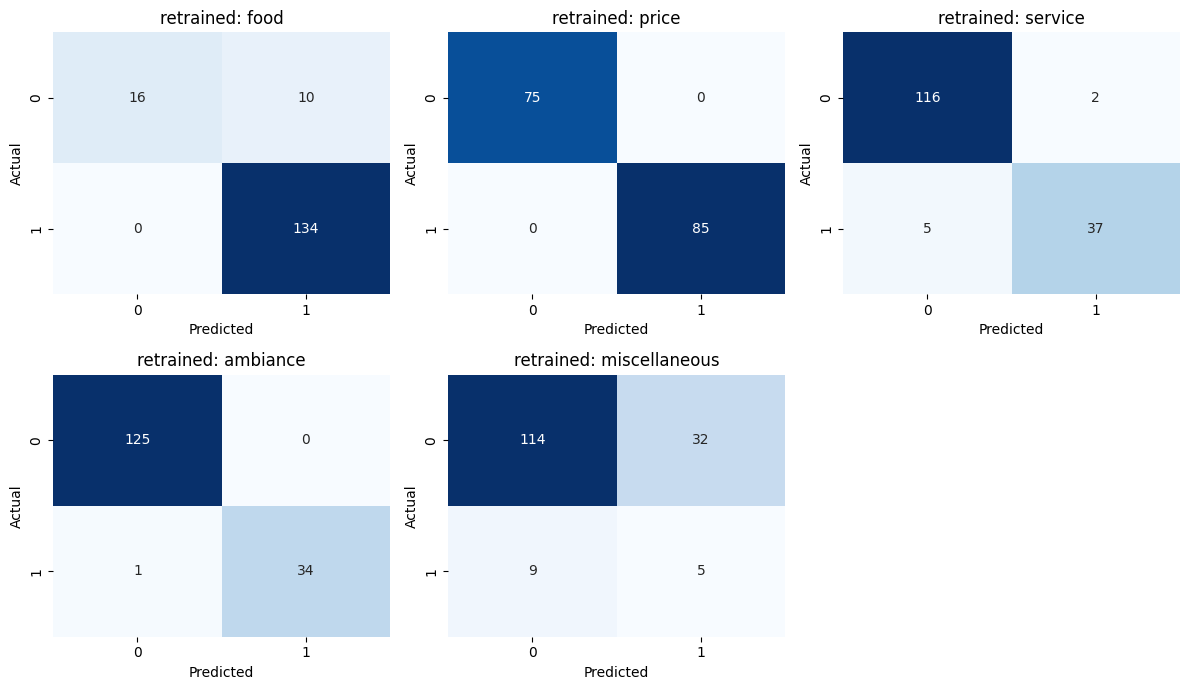

In [46]:
for encoder_name, result in evaluations.items():
    print(f"\n===== {encoder_name.upper()} =====")
    report_df = pd.DataFrame(result["report"]).T
    display(report_df)
    report_df.to_csv(
        OUTPUT_DIR / f"{encoder_name}_classification_report.csv"
    )

    matrices = multilabel_confusion_matrix(
        y_test,
        result["predictions"],
    )
    aspect_cols = result["metadata"]["aspect_cols"]

    fig, axes = plt.subplots(2, 3, figsize=(12, 7))
    for index, aspect in enumerate(aspect_cols):
        sns.heatmap(
            matrices[index],
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            ax=axes.flat[index],
        )
        axes.flat[index].set_title(f"{encoder_name}: {aspect}")
        axes.flat[index].set_xlabel("Predicted")
        axes.flat[index].set_ylabel("Actual")
    axes.flat[-1].axis("off")
    plt.tight_layout()
    plt.show()


## Retrained-model sample analysis

The following cells inspect exact-match predictions from the retrained encoder, display representative correct and incorrect reviews, and rank the clearest best and worst cases. The ranking is diagnostic only and does not change the model or thresholds.


In [47]:
RETRAINED_NAME = "retrained"
retrained_result = evaluations[RETRAINED_NAME]
retrained_metadata = retrained_result["metadata"]
retrained_probabilities = retrained_result["probabilities"]
retrained_predictions = retrained_result["predictions"]
retrained_aspects = retrained_metadata["aspect_cols"]


def labels_from_row(binary_row, aspect_cols):
    return [
        aspect
        for index, aspect in enumerate(aspect_cols)
        if binary_row[index] == 1
    ]


sample_rows = []
for row, review in enumerate(test_texts):
    true_row = y_test[row]
    predicted_row = retrained_predictions[row]
    probabilities_row = retrained_probabilities[row]

    true_positive_count = int(
        np.logical_and(true_row == 1, predicted_row == 1).sum()
    )
    false_positive_count = int(
        np.logical_and(true_row == 0, predicted_row == 1).sum()
    )
    false_negative_count = int(
        np.logical_and(true_row == 1, predicted_row == 0).sum()
    )
    denominator = (
        2 * true_positive_count
        + false_positive_count
        + false_negative_count
    )
    sample_f1 = (
        2 * true_positive_count / denominator
        if denominator
        else 1.0
    )

    false_positives = [
        retrained_aspects[index]
        for index in range(len(retrained_aspects))
        if true_row[index] == 0 and predicted_row[index] == 1
    ]
    false_negatives = [
        retrained_aspects[index]
        for index in range(len(retrained_aspects))
        if true_row[index] == 1 and predicted_row[index] == 0
    ]

    predicted_indices = np.flatnonzero(predicted_row)
    predicted_confidence = (
        float(probabilities_row[predicted_indices].mean())
        if len(predicted_indices)
        else 0.0
    )
    wrong_confidences = [
        float(probabilities_row[index])
        for index in range(len(retrained_aspects))
        if (
            true_row[index] != predicted_row[index]
        )
    ]

    sample_rows.append({
        "test_row": row,
        "dataset_index": int(test_idx[row]),
        "review": review,
        "true_labels": labels_from_row(true_row, retrained_aspects),
        "predicted_labels": labels_from_row(
            predicted_row,
            retrained_aspects,
        ),
        "exact_match": bool(np.array_equal(true_row, predicted_row)),
        "sample_f1": sample_f1,
        "error_count": false_positive_count + false_negative_count,
        "false_positives": false_positives,
        "false_negatives": false_negatives,
        "predicted_confidence": predicted_confidence,
        "maximum_wrong_confidence": (
            max(wrong_confidences)
            if wrong_confidences
            else 0.0
        ),
        **{
            f"prob_{aspect}": float(probabilities_row[index])
            for index, aspect in enumerate(retrained_aspects)
        },
    })

retrained_samples_df = pd.DataFrame(sample_rows)

print(
    "Exact matches:",
    int(retrained_samples_df["exact_match"].sum()),
    "/",
    len(retrained_samples_df),
)
print(
    "Incorrect samples:",
    int((~retrained_samples_df["exact_match"]).sum()),
)


Exact matches: 114 / 160
Incorrect samples: 46


### Correct and incorrect samples

Correct samples are exact label-set matches. Incorrect samples include at least one missing or extra aspect.


In [48]:
DISPLAY_COLUMNS = [
    "dataset_index",
    "review",
    "true_labels",
    "predicted_labels",
    "sample_f1",
    "false_positives",
    "false_negatives",
    "predicted_confidence",
]

correct_samples = (
    retrained_samples_df[
        retrained_samples_df["exact_match"]
    ]
    .sort_values(
        "predicted_confidence",
        ascending=False,
    )
)

incorrect_samples = (
    retrained_samples_df[
        ~retrained_samples_df["exact_match"]
    ]
    .sort_values(
        ["sample_f1", "error_count", "maximum_wrong_confidence"],
        ascending=[True, False, False],
    )
)

print("High-confidence correct samples")
display(correct_samples[DISPLAY_COLUMNS].head(10))

print("Incorrect samples")
display(incorrect_samples[DISPLAY_COLUMNS].head(15))


High-confidence correct samples


,dataset_index,review,true_labels,predicted_labels,sample_f1,false_positives,false_negatives,predicted_confidence
94,628,it is usually a little less salty than other d...,[food],[food],1.0,[],[],0.670648
56,314,the price of hilsa fish tail filling was also ...,"[food, price]","[food, price]",1.0,[],[],0.660511
105,204,the taste of kachchi is really unforgettable b...,"[food, price]","[food, price]",1.0,[],[],0.659236
68,356,the price of the food is high but the quality ...,"[food, price]","[food, price]",1.0,[],[],0.659235
65,548,there is no sweetness in the laddu bro and the...,"[food, price]","[food, price]",1.0,[],[],0.658980
0,692,although the price of the product has increase...,"[food, price]","[food, price]",1.0,[],[],0.658917
132,81,ilhasvajata is the same and the price is affor...,"[food, price]","[food, price]",1.0,[],[],0.658910
156,434,there was nothing sweet about lachchi and the ...,"[food, price]","[food, price]",1.0,[],[],0.658795
31,78,amrit taste but the price is a bit high,"[food, price]","[food, price]",1.0,[],[],0.658654
37,309,that is why the taste is slightly different an...,"[food, price]","[food, price]",1.0,[],[],0.658621


Incorrect samples


,dataset_index,review,true_labels,predicted_labels,sample_f1,false_positives,false_negatives,predicted_confidence
110,424,the food here tastes a little better but nothi...,"[food, miscellaneous]","[food, service]",0.500000,[service],[miscellaneous],0.602149
28,599,the pizza was delicious but the experience was...,"[food, miscellaneous]","[food, service]",0.500000,[service],[miscellaneous],0.596810
111,451,this restaurant is being cooked by foreign coo...,"[price, miscellaneous]","[food, price]",0.500000,[food],[miscellaneous],0.613071
77,569,they are giving free toys to children which is...,"[price, miscellaneous]","[food, price]",0.500000,[food],[miscellaneous],0.609622
78,593,food of normal price is very scarce here and t...,"[price, service]","[food, price]",0.500000,[food],[service],0.583520
152,365,food prices are lower than other nearby places...,[price],"[food, price, miscellaneous]",0.500000,"[food, miscellaneous]",[],0.532965
117,479,ordering lower priced items made the waiters e...,"[price, service]","[food, price]",0.500000,[food],[service],0.561106
26,260,a restaurant and location is also very good to...,"[price, miscellaneous]","[food, price]",0.500000,[food],[miscellaneous],0.580968
159,360,some fake restaurants and food prices are high...,"[price, miscellaneous]","[food, price]",0.500000,[food],[miscellaneous],0.587475
12,634,schizlingter is a type of food that is served ...,"[food, service]","[food, miscellaneous]",0.500000,[miscellaneous],[service],0.578377


### Best cases

Best cases are exact matches with the highest average probability across predicted labels. They show review patterns the retrained model recognizes most clearly.


In [49]:
best_cases = correct_samples.head(10).copy()
display(
    best_cases[
        DISPLAY_COLUMNS
        + [f"prob_{aspect}" for aspect in retrained_aspects]
    ]
)

print("Most common true-label combinations among exact matches:")
display(
    correct_samples["true_labels"]
    .apply(lambda labels: " + ".join(labels))
    .value_counts()
    .rename_axis("label_combination")
    .reset_index(name="correct_samples")
    .head(10)
)


,dataset_index,review,true_labels,predicted_labels,sample_f1,false_positives,false_negatives,predicted_confidence,prob_food,prob_price,prob_service,prob_ambiance,prob_miscellaneous
94,628,it is usually a little less salty than other d...,[food],[food],1.0,[],[],0.670648,0.670648,0.435204,0.410583,0.424859,0.497253
56,314,the price of hilsa fish tail filling was also ...,"[food, price]","[food, price]",1.0,[],[],0.660511,0.646123,0.674899,0.311370,0.335758,0.418479
105,204,the taste of kachchi is really unforgettable b...,"[food, price]","[food, price]",1.0,[],[],0.659236,0.642091,0.676382,0.313848,0.335636,0.417803
68,356,the price of the food is high but the quality ...,"[food, price]","[food, price]",1.0,[],[],0.659235,0.638021,0.680448,0.315479,0.333722,0.417377
65,548,there is no sweetness in the laddu bro and the...,"[food, price]","[food, price]",1.0,[],[],0.658980,0.638808,0.679152,0.314526,0.333106,0.419787
0,692,although the price of the product has increase...,"[food, price]","[food, price]",1.0,[],[],0.658917,0.638317,0.679518,0.314545,0.334012,0.417950
132,81,ilhasvajata is the same and the price is affor...,"[food, price]","[food, price]",1.0,[],[],0.658910,0.640325,0.677494,0.313804,0.334988,0.419557
156,434,there was nothing sweet about lachchi and the ...,"[food, price]","[food, price]",1.0,[],[],0.658795,0.648268,0.669322,0.314609,0.336238,0.417878
31,78,amrit taste but the price is a bit high,"[food, price]","[food, price]",1.0,[],[],0.658654,0.639564,0.677745,0.312134,0.336896,0.418462
37,309,that is why the taste is slightly different an...,"[food, price]","[food, price]",1.0,[],[],0.658621,0.644865,0.672378,0.316016,0.331922,0.421250


Most common true-label combinations among exact matches:


,label_combination,correct_samples
0,food + price,67
1,food + service,30
2,food + ambiance,10
3,food + miscellaneous,3
4,food,1
5,ambiance + miscellaneous,1
6,price + ambiance,1
7,price + miscellaneous,1


### Worst cases

Worst cases prioritize the lowest sample-level F1, then the largest number of label errors, then the highest confidence assigned to a wrong decision. These cases are useful for identifying label ambiguity, noisy translations, missing training patterns, and threshold problems.


In [50]:
worst_cases = incorrect_samples.head(15).copy()
display(
    worst_cases[
        DISPLAY_COLUMNS
        + ["maximum_wrong_confidence"]
        + [f"prob_{aspect}" for aspect in retrained_aspects]
    ]
)

worst_cases.to_csv(
    OUTPUT_DIR / "retrained_worst_cases.csv",
    index=False,
)
correct_samples.head(25).to_csv(
    OUTPUT_DIR / "retrained_best_cases.csv",
    index=False,
)
retrained_samples_df.to_csv(
    OUTPUT_DIR / "retrained_sample_predictions.csv",
    index=False,
)


,dataset_index,review,true_labels,predicted_labels,sample_f1,false_positives,false_negatives,predicted_confidence,maximum_wrong_confidence,prob_food,prob_price,prob_service,prob_ambiance,prob_miscellaneous
110,424,the food here tastes a little better but nothi...,"[food, miscellaneous]","[food, service]",0.500000,[service],[miscellaneous],0.602149,0.597917,0.606382,0.328436,0.597917,0.440243,0.490985
28,599,the pizza was delicious but the experience was...,"[food, miscellaneous]","[food, service]",0.500000,[service],[miscellaneous],0.596810,0.586950,0.606670,0.336384,0.586950,0.442017,0.496339
111,451,this restaurant is being cooked by foreign coo...,"[price, miscellaneous]","[food, price]",0.500000,[food],[miscellaneous],0.613071,0.558183,0.558183,0.667959,0.356982,0.363082,0.450653
77,569,they are giving free toys to children which is...,"[price, miscellaneous]","[food, price]",0.500000,[food],[miscellaneous],0.609622,0.554527,0.554527,0.664717,0.362117,0.365315,0.446775
78,593,food of normal price is very scarce here and t...,"[price, service]","[food, price]",0.500000,[food],[service],0.583520,0.534280,0.534280,0.632761,0.437485,0.344606,0.445967
152,365,food prices are lower than other nearby places...,[price],"[food, price, miscellaneous]",0.500000,"[food, miscellaneous]",[],0.532965,0.529273,0.446737,0.622886,0.386425,0.444593,0.529273
117,479,ordering lower priced items made the waiters e...,"[price, service]","[food, price]",0.500000,[food],[service],0.561106,0.528058,0.528058,0.594153,0.486361,0.349038,0.440127
26,260,a restaurant and location is also very good to...,"[price, miscellaneous]","[food, price]",0.500000,[food],[miscellaneous],0.580968,0.523443,0.523443,0.638493,0.342067,0.435863,0.478176
159,360,some fake restaurants and food prices are high...,"[price, miscellaneous]","[food, price]",0.500000,[food],[miscellaneous],0.587475,0.517599,0.517599,0.657351,0.341884,0.412368,0.484065
12,634,schizlingter is a type of food that is served ...,"[food, service]","[food, miscellaneous]",0.500000,[miscellaneous],[service],0.578377,0.502671,0.654799,0.374852,0.502671,0.423002,0.501954


### Per-aspect error analysis

This table identifies whether each aspect mainly suffers from false positives or false negatives. High false positives suggest raising the threshold; high false negatives suggest lowering it or adding more representative training examples.


In [51]:
aspect_error_rows = []

for index, aspect in enumerate(retrained_aspects):
    true_values = y_test[:, index]
    predicted_values = retrained_predictions[:, index]

    true_positives = int(
        np.logical_and(true_values == 1, predicted_values == 1).sum()
    )
    false_positives = int(
        np.logical_and(true_values == 0, predicted_values == 1).sum()
    )
    false_negatives = int(
        np.logical_and(true_values == 1, predicted_values == 0).sum()
    )
    true_negatives = int(
        np.logical_and(true_values == 0, predicted_values == 0).sum()
    )

    aspect_error_rows.append({
        "aspect": aspect,
        "threshold": retrained_metadata["thresholds"][aspect],
        "true_positives": true_positives,
        "false_positives": false_positives,
        "false_negatives": false_negatives,
        "true_negatives": true_negatives,
        "f1": f1_score(
            true_values,
            predicted_values,
            zero_division=0,
        ),
        "main_error_type": (
            "false positives"
            if false_positives > false_negatives
            else "false negatives"
            if false_negatives > false_positives
            else "balanced"
        ),
    })

aspect_error_df = (
    pd.DataFrame(aspect_error_rows)
    .sort_values("f1")
    .reset_index(drop=True)
)

aspect_error_df.to_csv(
    OUTPUT_DIR / "retrained_aspect_error_analysis.csv",
    index=False,
)
display(aspect_error_df)


,aspect,threshold,true_positives,false_positives,false_negatives,true_negatives,f1,main_error_type
0,miscellaneous,0.50,5,32,9,114,0.196078,false positives
1,service,0.52,37,2,5,116,0.913580,false negatives
2,food,0.43,134,10,0,16,0.964029,false positives
3,ambiance,0.52,34,0,1,125,0.985507,false negatives
4,price,0.44,85,0,0,75,1.000000,balanced


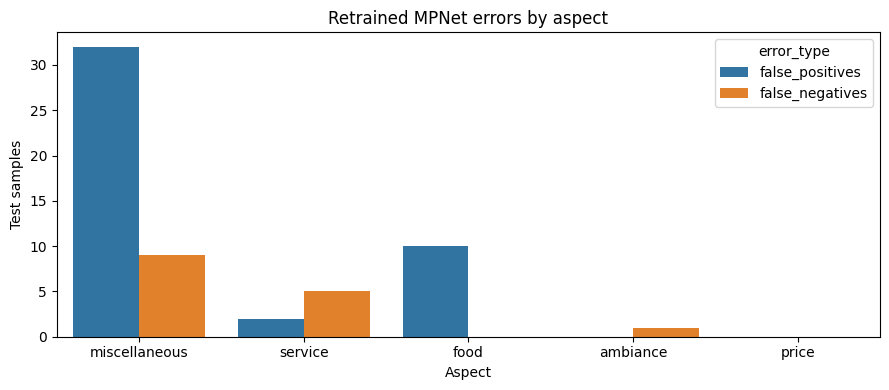

In [52]:
error_plot_df = aspect_error_df.melt(
    id_vars="aspect",
    value_vars=["false_positives", "false_negatives"],
    var_name="error_type",
    value_name="count",
)

plt.figure(figsize=(9, 4))
sns.barplot(
    data=error_plot_df,
    x="aspect",
    y="count",
    hue="error_type",
)
plt.title("Retrained MPNet errors by aspect")
plt.ylabel("Test samples")
plt.xlabel("Aspect")
plt.tight_layout()
plt.show()
